# 회귀와 평가지표

1. 회귀란 무엇인가?
2. 같은 피처, 정답만 바꾸면 어떻게될까?
3. 회귀의 다양한 알고리즘.
4. 회귀 평가지표(MAE, MSE, RMSE, R^2)
5. 잔차분석

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)

df = build_dataset()            
train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

X_train, X_test = tr[FEATURES], te[FEATURES]

y_train_분류, y_test_분류 = tr["target_up"], te["target_up"]
y_train_회귀, y_test_회귀 = tr["target_ret"], te["target_ret"]


print(f" 학습 {len(tr):,}행 ({tr.date.min().date()} ~ {tr.date.max().date()})")
print(f" 테스트 {len(te):,}행 ({te.date.min().date()} ~ {te.date.max().date()})")
print(f" 피처 {len(FEATURES)}개")
print()
print(f"분류용 target_up : {y_train_분류.unique()} (범주)")
print(f"회귀용 target_ret : {y_train_회귀.min():.4f} ~ {y_train_회귀.max():.4f} (수치)")

[폰트] Malgun Gothic / unicode_minus=False
 학습 15,000행 (2023-10-24 ~ 2026-01-16)
 테스트 4,000행 (2026-01-19 ~ 2026-08-07)
 피처 7개

분류용 target_up : [0 1] (범주)
회귀용 target_ret : -0.2260 ~ 0.2313 (수치)


---
# 회귀란 무엇인가?
> 수치를 예측하는 문제다.

||분류|회귀|
|---|---|---|
|예측|up/down|2.7|
|맞다/틀리다|명확함|개념이 없음|
|평가|몇 개를 맞혔냐|얼마나 빗나갔나|

### 정확하게 맞혔다가 없다!
수익률을 2.7%로 예측했는데 2.71%가 나오면 맞힌걸까? 틀린건가?

둘 다 아니다. 회귀에서는 얼마나 가까운가? 그것이 중요하다. 오차의 크기를 잰다.

**로지스틱회귀는 분류모델이다**

내부에서 선형 회귀를 계산한 뒤에 그 값을 0~1확률로 넘기기 때문에 분류로 한다.

---
# 같은 피처, 정답만 바꾸면 어떻게될까?

피처는 그대로두고 y먼 변경한다.

분류 y = target_up (0/1) -> RandomForestClassifier
회귀 y = target_ret (수익률) -> RandomForestRegressor

**같은 알고리즘인데 평가 방법이 완전히 달라진다.**

In [3]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# 이름 끝만 다르다. RandomForestClassifier, RandomForestRegressor
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
reg = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)

clf.fit(X_train, y_train_분류)
reg.fit(X_train, y_train_회귀)

pred_분류 = clf.predict(X_test)
pred_회귀 = reg.predict(X_test)

print(f"{'':<14}{'분류':<32}{'회귀'}")
print("-"*70)
print(f"{'정답예시':<13}{str(y_test_분류.iloc[0]):32}{y_test_회귀.iloc[0]:.4f}")
print(f"{'예측예시':<13}{str(pred_분류[0]):32}{pred_회귀[0]:.4f}")
print()
print(f"분류평가 정확도 {accuracy_score(y_test_분류, pred_분류):.4f}"
      f"    F1  {f1_score(y_test_분류, pred_분류):.4f}")
print(f"회귀평가 RMSE {np.sqrt(mean_squared_error(y_test_회귀, pred_회귀)):.6f}"
      f"    R^2  {r2_score(y_test_회귀, pred_회귀):.4f}")



              분류                              회귀
----------------------------------------------------------------------
정답예시         0                               -0.0068
예측예시         1                               -0.0000

분류평가 정확도 0.4933    F1  0.4269
회귀평가 RMSE 0.027389    R^2  -0.0068


In [4]:
# 회귀 예측을 0 기준으로 잘라서 분류로 변경하면?

회귀를_분류로 = (pred_회귀 > 0).astype(int)

print(f"회귀 모델 예측을 0 기준으로 자른 정확도 : "
      f"{accuracy_score(y_test_분류, 회귀를_분류로):.4f}")
print(f"처음부터 분류로 학습한 정확도 : "
      f"{accuracy_score(y_test_분류, pred_분류):.4f}")
print()

# 비슷하게 나온다. 같은 정보를 다르게 요약한 것이기 때문에 
# 다만 회귀는 '얼마나'를 알려주고, 분류는 '어느 쪽인지'만 알려준다.

회귀 모델 예측을 0 기준으로 자른 정확도 : 0.4793
처음부터 분류로 학습한 정확도 : 0.4933



**값의 형태가 다르기 때문에 평가지표를 섞어 쓸 수는 없다**

회귀모델에 정확도를 물을 수 있을까? -> 2.7%예상했는데 2.71%이라면 애~~매하다.

분류에서는 혼동행렬로 TP,FN를 셌다. 회귀에는 셀 것이 없다. 대신 예측값과 실제값의 차이(잔차)를 어떻게 요약해서 볼것인가?

---
# LinearRegression

가장 단순한 선형 회귀 모델이다. **직선으로 관례를 표현**한다.

```
예측값 = w1*수익률 + w2*이동평균비율 + w3*변동성 + ... + b
```

학습이란 **오차가 가장 작아지는 w와 b를 찾는 것**이다.

w = 가중치,
b = 편향

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 계수를 비교하려면 스케일링이 먼저입니다.
lin = Pipeline([("sc", StandardScaler()), ("m", LinearRegression())])
lin.fit(X_train, y_train_회귀)

# lin.named_steps["m"] : 머신러닝 파이프라인 객체에서 이름이 m으로 지정된 모델을 가져온다.
# 모델.coef_는 가중치 배열
계수 = pd.Series(lin.named_steps["m"].coef_, index=FEATURES).sort_values()
# 모델.intercept_ 편향 값
절편 = lin.named_steps["m"].intercept_

print(f"절편 (b) : {절편:.6f}")
print()
print("계수 (w) : ")
print(계수.round(6).to_string())

절편 (b) : -0.000063

계수 (w) : 
vol20          -0.000567
ma20_ratio     -0.000507
volume_ratio   -0.000161
range_pct       0.000055
ma5_ratio       0.000117
ret_5d          0.000544
ret_1d          0.000756


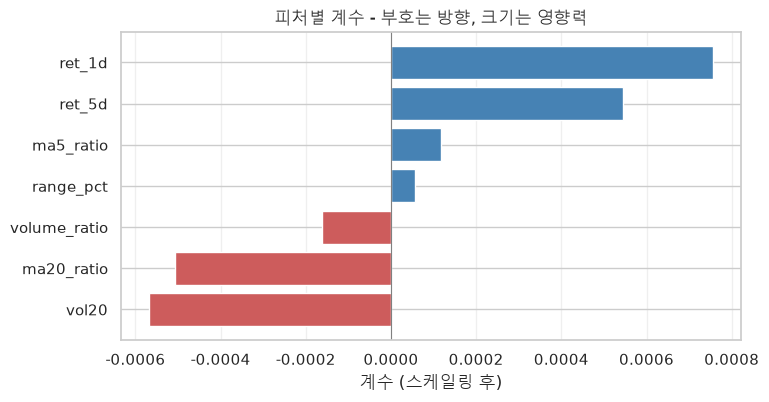

In [6]:
fig, ax = plt.subplots(figsize=(8,4))

colors = ["indianred" if v < 0 else "steelblue" for v in 계수.values]

ax.barh(계수.index, 계수.values, color=colors)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("계수 (스케일링 후)")
ax.set_title("피처별 계수 - 부호는 방향, 크기는 영향력")
ax.grid(alpha=0.3, axis="x")
plt.show()

**계수가 해석을 도와준다**

w가 크면 그 피처가 예측에 크게 기여한다라는 뜻이고, 부호는 방향을 알려준다.

다만 스케일이 다르면 계수 크기를 직접 비교할 수 없기때문에 스케일링을 먼저 해줘야한다.

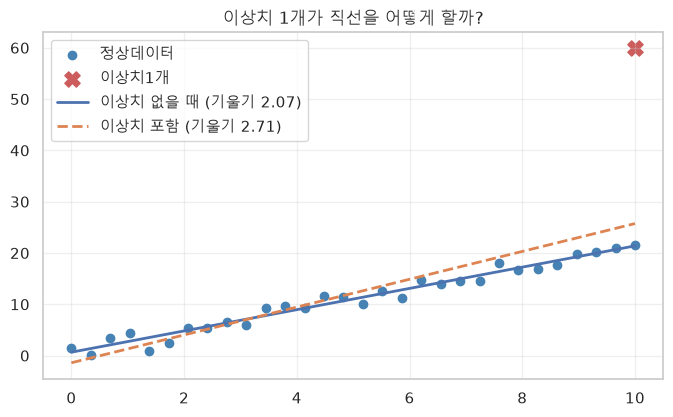

In [7]:
# 이상치 하나 넣어서 어느정도 끌려가는지 보자

rng = np.random.default_rng(SEED) # 난수생성기
x_demo = np.linspace(0, 10, 30) # 0~10까지 범위를 균등하게 30개 구간으로 나눈 숫자배열
# 실제 데이터처럼 생성
# + 노이즈(평균0, 표준편차 1.5인 오차 30개)
y_demo = 2 * x_demo + 1 + rng.normal(0, 1.5, 30) 

x_bad = np.append(x_demo, 10)
y_bad = np.append(y_demo, 60)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_demo, y_demo, label="정상데이터", color="steelblue")
ax.scatter([10], [60], s=120, label="이상치1개", color="indianred", marker="X", zorder=-5)

for xs, ys, style, label in [
    (x_demo, y_demo, "-", "이상치 없을 때"),
    (x_bad, y_bad, "--", "이상치 포함"),
]:
    m = LinearRegression().fit(xs.reshape(-1, 1), ys)
    xx = np.linspace(0, 10, 10)
    ax.plot(xx, m.predict(xx.reshape(-1, 1)), style, lw=2,
            label=f"{label} (기울기 {m.coef_[0]:.2f})")


ax.legend()
ax.grid(alpha=0.3)
ax.set_title("이상치 1개가 직선을 어떻게 할까?")
plt.show()


**이상치 한개가 직선을 끌고간다**

선형회귀는 오차의 제곱을 최소화합니다. 크게 빗나간 점 하나가 제곱되면서 영향력이 커진다.

---
# 규제회귀 - Ridge, Lasso, ElasticNet

피처가 많아지며 모델이 학습 데이터의 잡음까지 외운다. 계수가 비정상적으로 커지면서 과적합이 일어난다.
규제는 계수가 커지는 것에 벌점을 줘서 이를 막는 것이다.

||Ridge(L2)|Lasso(L1)|ElasticNet|
|---|---|---|---|
|벌점|계수의 제곱|계수의 절댓값|둘을 섞음|
|효과|계수를 작게|일부를 0으로|중간|
|결과|모든 피처 유지|피처 선택 효과| 상관된 피처에 강함 |

In [8]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

def make(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# 규제회귀의 alpha(규제강도)가 커질수록 모델의 복잡도가 낮아지고 과적합을 방지, 다만 너무 커지면 미달적합이 발생한다.
models = {
    "Linear": make(LinearRegression()),  # 기본선형회귀
    "Ridge(a=1)": make(Ridge(alpha=1.0)), # 규제강도 약한 Ridge -> 가중치를 조금 줄인모델
    "Ridge(a=1000)": make(Ridge(alpha=1000)), # 규제강도 매우강한 Ridge -> 가중치를 거의 0에 가깝게 줄인모델
    "Lasso(a=1e-4)": make(Lasso(alpha=1e-4)), # 아주약한  Lasso -> 가중치를 조금 줄인모델
    "Lasso(a=1e-3)": make(Lasso(alpha=1e-3)), # 조금더강한 Lasso -> 불필요한 특성의 계수를 0으로 만들어서 제거할 수 있다.
    "ElasticNet": make(ElasticNet(alpha=1e-4, l1_ratio=0.5)),
}

rows = {}
for name, m in models.items():
    m.fit(X_train, y_train_회귀)
    rows[name] = m.named_steps["m"].coef_

rows_df = pd.DataFrame(rows, index=FEATURES)
print(rows_df.round(6).to_string())

print()
for col in ["Lasso(a=1e-4)", "Lasso(a=1e-3)"]:
    d = [f for f, v in rows_df[col].items() if v == 0]
    print(f"{col:<16} 0이 된 피처 {len(d)}개 {d}")



                Linear  Ridge(a=1)  Ridge(a=1000)  Lasso(a=1e-4)  Lasso(a=1e-3)  ElasticNet
ret_1d        0.000756    0.000756       0.000657       0.000659            0.0    0.000707
ret_5d        0.000544    0.000544       0.000380       0.000132            0.0    0.000339
ma5_ratio     0.000117    0.000117       0.000235       0.000133            0.0    0.000124
ma20_ratio   -0.000507   -0.000506      -0.000392      -0.000058            0.0   -0.000282
vol20        -0.000567   -0.000567      -0.000528      -0.000460            0.0   -0.000510
volume_ratio -0.000161   -0.000161      -0.000151      -0.000058            0.0   -0.000107
range_pct     0.000055    0.000055       0.000046       0.000000            0.0    0.000000

Lasso(a=1e-4)    0이 된 피처 1개 ['range_pct']
Lasso(a=1e-3)    0이 된 피처 7개 ['ret_1d', 'ret_5d', 'ma5_ratio', 'ma20_ratio', 'vol20', 'volume_ratio', 'range_pct']


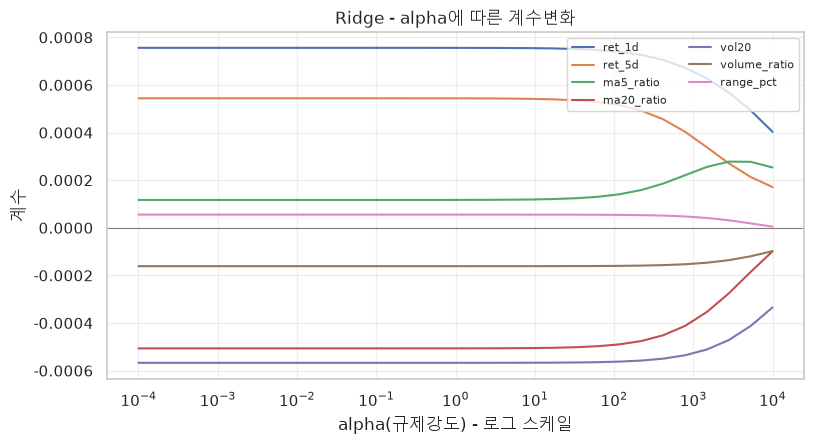

In [11]:
# alpha를 키우면 계수가 어떻게 줄어드는지 직접확인하면 진행

alphas = np.logspace(-4, 4, 30) # 0.0001~10000까지 로그 스케일간격으로 30개의 alpha후보 생성
path = []

for a in alphas:
    m = make(Ridge(alpha=a))
    m.fit(X_train, y_train_회귀)
    path.append(m.named_steps["m"].coef_)

path = np.array(path)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, f in enumerate(FEATURES):
    ax.plot(alphas, path[:, i], label=f)

ax.set_xscale("log")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("alpha(규제강도) - 로그 스케일")
ax.set_ylabel("계수")
ax.set_title("Ridge - alpha에 따른 계수변화")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.show()



**alpha를 너무 키우면 과소적합이 된다.**

규제가 강해질수록 계수가 전부 0에 가까워지고, 아무것도 학습할 수 없다. 그림과같이 0으로 전부 수렴한다.

적절한 값은 데이터마다 다르다.

**Lasso는 피처를 골라준다.**
불필요한 피처의 계수를 아예 0으로 만들어 모델에서 제외한다. 위 표에서 a=1e-4는 일부만 떨어뜨리고 크게 없애는 값이 없지만 a=le-3일 때는 전부 0으로 만들었다.

alpha값은 계수의 크기에 맞춰 정해야한다.
